In [1]:
import geopandas as gpd
from shapely.geometry import MultiPolygon
import pandas as pd
from shapely import wkt
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from equi7grid_lite import Equi7Grid
from dotenv import load_dotenv
import os
from pathlib import Path
import json

# Set font sizes for various components
plt.rcParams.update({
    'font.size': 14,           # Global font size
    'axes.titlesize': 18,      # Title font size
    'axes.labelsize': 16,      # X and Y label font size
    'xtick.labelsize': 14,     # X tick label font size
    'ytick.labelsize': 14,     # Y tick label font size
})

# Create Grid

In [3]:
def get_region_shape(path, region_id):
    
    usa = gpd.read_file(path)
    country = usa[usa.REGION == region_id]
    
    region = country.explode()[0:1] 

    return region
    

In [4]:
def generate_equi7_grid(usa_filepath, resolution, pixel_size, region_id, output_shapefile):
    size = resolution * pixel_size
    print(f"Resolution: {resolution}, Pixel Size: {pixel_size}, Minimum Grid Size: {size}")
    
    # Initialize the Equi7 grid system
    grid_system = Equi7Grid(min_grid_size=size)
    
    # Load and filter the USA shapefile
    usa = gpd.read_file(usa_filepath)
    country = usa[usa['REGION'] == region_id]
    region = country.explode().reset_index(drop=True)
    
    if len(region) == 0:
        raise ValueError(f"No region found with ID {region_id}")
    
    # Ensure 'region' is a GeoDataFrame
    if not isinstance(region, gpd.GeoDataFrame):
        region = gpd.GeoDataFrame(region, geometry='geometry')
    
    # Generate the Equi7 grid
    print("Generating grid...")
    grid = grid_system.create_grid(
        level=0,
        zone="NA",
        mask=region  # Ensure 'region' is a GeoDataFrame with CRS
    )
    
    # Plot and save the grid boundaries
    ax = grid.boundary.plot()
    plt.title(f'Equi7 Grid Boundaries Region {region_id}')
    plt.savefig(f"{output_shapefile.replace('.shp', '.png')}")
    plt.show()
    
    # Save the grid to shapefile
    grid.to_file(output_shapefile)
    print(f"Grid saved to {output_shapefile}")

    return grid


In [5]:
def create_convex_hulls(refdm, ids, output_path):
    """
    Create and save convex hulls from REFDM data and USDA polygon IDs by 
    spatially joining and generating convex hulls for each USDA_IDX.

    Parameters:
    - refdm_path: Path to the REFDM shapefile.
    - ids_path: Path to the USDA polygon IDs shapefile.
    - output_path: Path to save the resulting convex hulls shapefile.

    Returns:
    - convex_hulls_gdf: A GeoDataFrame containing the convex hulls.
    """
    

    # Step 2: Dissolve REFDM geometries by 'USDA_IDX'
    dissolved_refdm = refdm[['IDX_D', 'geometry']].dissolve(by='IDX_D').reset_index()
    print(f"Number of dissolved geometries: {len(dissolved_refdm)}")
    
    # Step 3: Spatial join between dissolved REFDM geometries and USDA IDs
    merged_gdf = gpd.sjoin(dissolved_refdm, ids, how='left', predicate='intersects', on_attribute=['IDX_D'])
    
    # Step 4: Group merged geometries by 'USDA_IDX' and combine them using unary union
    merged_geometries = merged_gdf.groupby('IDX_D')['geometry'].apply(lambda x: x.unary_union)
    
    # Step 5: Create convex hulls for each grouped geometry
    convex_hulls = merged_geometries.apply(lambda geom: MultiPolygon([geom.convex_hull]))
    
    # Step 6: Create a new GeoDataFrame for the convex hulls with the same CRS as REFDM
    convex_hulls_gdf = gpd.GeoDataFrame(geometry=convex_hulls, crs=refdm.crs).reset_index()
    
    # Step 7: Save convex hulls to the specified shapefile path
    convex_hulls_gdf.to_file(output_path)
    print(f"Convex hulls saved to {output_path}")
    
    return convex_hulls_gdf

In [6]:
def intersect_grid(convex_hulls_gdf, grid_gdf, output_shapefile_path, output_figure_path, target_crs, region=None, region_id=None):
    """
    Perform spatial join between convex hulls and grid, plot, and save the results.

    Parameters:
    - convex_hulls_gdf: GeoDataFrame of convex hulls.
    - grid_gdf: GeoDataFrame of grid.
    - output_shapefile_path: File path to save the intersected grid as a shapefile.
    - output_figure_path: File path to save the figure as an image.
    - target_crs: Target Coordinate Reference System (CRS) to project geometries.
    - region: Optional GeoDataFrame for a specific region boundary (optional).
    - region_id: ID of the region to be displayed in the plot title (optional).

    Returns:
    - intersected_gdf_equi7: GeoDataFrame of intersected grids with convex hulls.
    """
    # Perform spatial join between the grid and convex hulls
    intersected_gdf_equi7 = gpd.sjoin(grid_gdf, convex_hulls_gdf, how='inner', predicate='intersects')
    
    # Clean the intersected data
    intersected_gdf_equi7 = (
        intersected_gdf_equi7
        .drop(columns=['index_right', 'IDX_D', 'level', 'land', 'zone'])
        .drop_duplicates()
        .reset_index(drop=True)
    )
    
    # Save the intersected GeoDataFrame as a shapefile
    intersected_gdf_equi7.to_file(output_shapefile_path)
    print(f"Intersected grids saved to: {output_shapefile_path}")
    
    # Plot intersected geometries and region boundary (if provided)
    fig, ax = plt.subplots(figsize=(12, 12))  # Adjust size as needed
    
    # Plot the intersected grids
    intersected_gdf_equi7.boundary.plot(
        ax=ax, color='black', linewidth=0.6, linestyle='-', zorder=2,
        label=f'Intersected Grids ({len(intersected_gdf_equi7)})'
    )
    
    # If region is provided, plot its boundary
    if region is not None:
        region = region.to_crs(target_crs)
        region.boundary.plot(
            ax=ax, color='red', linewidth=0.5, linestyle='--', zorder=3,
            label=f'Region {region_id} Boundary'
        )
    
    # Customize plot appearance
    ax.set_title(f'Intersected Grids with EQUI7 NA Grid and Region {region_id} Boundary', fontsize=18, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_aspect('equal')  # Keep aspect ratio
    
    # Add legend
    ax.legend(loc='upper left', fontsize=12)
    
    # Save the plot as an image
    plt.savefig(output_figure_path, dpi=300)
    print(f"Plot saved to: {output_figure_path}")
    
    # Display the plot
    plt.show()
    
    return intersected_gdf_equi7


In [17]:
import os
import time
from pathlib import Path
import geopandas as gpd
from tqdm import tqdm  # For progress bars
from dotenv import load_dotenv

# Load environment variables from the .env file
env_path = Path('/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/environment/.env')
load_dotenv(dotenv_path=env_path)

# Retrieve environment variables
s2_minicubes_folder = os.getenv('EQUI7_GRIDS')
print(f"Equi7 grids folder: {s2_minicubes_folder}")

# Retrieve the CRS (Coordinate Reference System) for Equi7 NA
equi7_crs = os.getenv('EQUI7_NA_EPSG')

# Ensure the 'REGION' environment variable is set
region = os.getenv('REGION')
if region is None:
    raise ValueError("The 'REGION' environment variable is not set. Please ensure it is defined in the .env file.")

# Format region ID as a two-digit string
region_id = str(region).zfill(2)

# Parameters for the grid
resolution = 10
pixel_size = 512

# Define file paths for shapefiles and output locations
usa_filepath = f"{os.getenv('REGION_SHAPE')}/S_USA.AdministrativeRegion.shp"
ids_path = f"{os.getenv('RESULTS')}/region{region_id}_dca_filtered_ids_usda_polygons.shp"
refdm_path = f"{os.getenv('RESULTS')}/radar_results/radar_enhanced_forest_disturbance_mapping_region_{region_id}.shp"
output_path_grid = f"{s2_minicubes_folder}/grid_equi7_{resolution}_{pixel_size}_region_{region_id}.shp"
output_path_conves = f"{os.getenv('RESULTS')}/radar_results/convex_hulls_refdm_region_{region_id}_epsg_4326.shp"
output_path_intersetion = f"{s2_minicubes_folder}/grid_equi7_{resolution}_{pixel_size}_region_{region_id}_intersetion.shp"
output_figure_intersection = f"{os.getenv('FIGURES')}/p1_f4_grid_equi7_{resolution}_{pixel_size}_region_{region_id}_intersetion.png"

# Function to load region shape from USA boundary shapefile
region_shape = get_region_shape(usa_filepath, region_id=region_id)

# Step 1: Read the REFDM and USDA IDs shapefiles
print(f"Loading REFDM shapefile from: {refdm_path}")
refdm_gdf = gpd.read_file(refdm_path)

print(f"Loading USDA IDs shapefile from: {ids_path}")
ids_gdf = gpd.read_file(ids_path)

# Step 2: Generate the Equi7 grid and save it as a shapefile
print("\nGenerating the Equi7 grid...")
start_time_grid = time.time()  # Start timer for grid creation

grid = generate_equi7_grid(
    usa_filepath=usa_filepath,
    resolution=resolution,
    pixel_size=pixel_size,
    region_id=region_id,
    output_shapefile=output_path_grid
)

# Print the time taken to generate the grid
print(f"Grid generation completed in {time.time() - start_time_grid:.2f} seconds.")
print(f"Grid saved to: {output_path_grid}\n")

# Step 3: Create convex hulls from the REFDM and USDA shapefiles
print("Creating convex hulls from REFDM and USDA polygons...")

# Use tqdm to display a progress bar during convex hull creation
start_time_convex = time.time()  # Start timer for convex hull creation

convex_hulls = create_convex_hulls(refdm_gdf, ids_gdf, output_path_conves)

# Print the time taken for convex hull creation
print(f"Convex hull creation completed in {time.time() - start_time_convex:.2f} seconds.")
print(f"Convex hulls saved to: {output_path_conves}\n")

# Step 4: Reproject the convex hulls to Equi7 CRS
print(f"Reprojecting convex hulls to CRS: {equi7_crs}")
reprojected_convex_hulls = convex_hulls.to_crs(equi7_crs)
print(f"Reprojection completed.\n")

# Plot the grid (optional, can be removed if not needed)
grid.plot()

# Step 5: Intersect the reprojected convex hulls with the grid and save the result
print("Performing spatial intersection between convex hulls and grid...")
start_time_intersection = time.time()

intersected = intersect_grid(
    reprojected_convex_hulls,
    grid,
    output_path_intersetion,
    output_figure_intersection,
    equi7_crs,
    region=region_shape,
    region_id=region_id
)

# Print the time taken for intersection
print(f"Intersection completed in {time.time() - start_time_intersection:.2f} seconds.")
print(f"Intersected grid saved to: {output_path_intersetion}")
print(f"Intersection plot saved to: {output_figure_intersection}\n")

# Print a message indicating the script has finished
print("Process completed successfully!\n")


Equi7 grids folder: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/grids/
Loading REFDM shapefile from: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results//radar_results/radar_enhanced_forest_disturbance_mapping_region_08.shp
Loading USDA IDs shapefile from: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results//region08_dca_filtered_ids_usda_polygons.shp


/tmp/ipykernel_353959/42259794.py:12: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax[0].legend(fontsize=12)  # Larger legend
/tmp/ipykernel_353959/42259794.py:20: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax[1].legend(fontsize=12)  # Larger legend


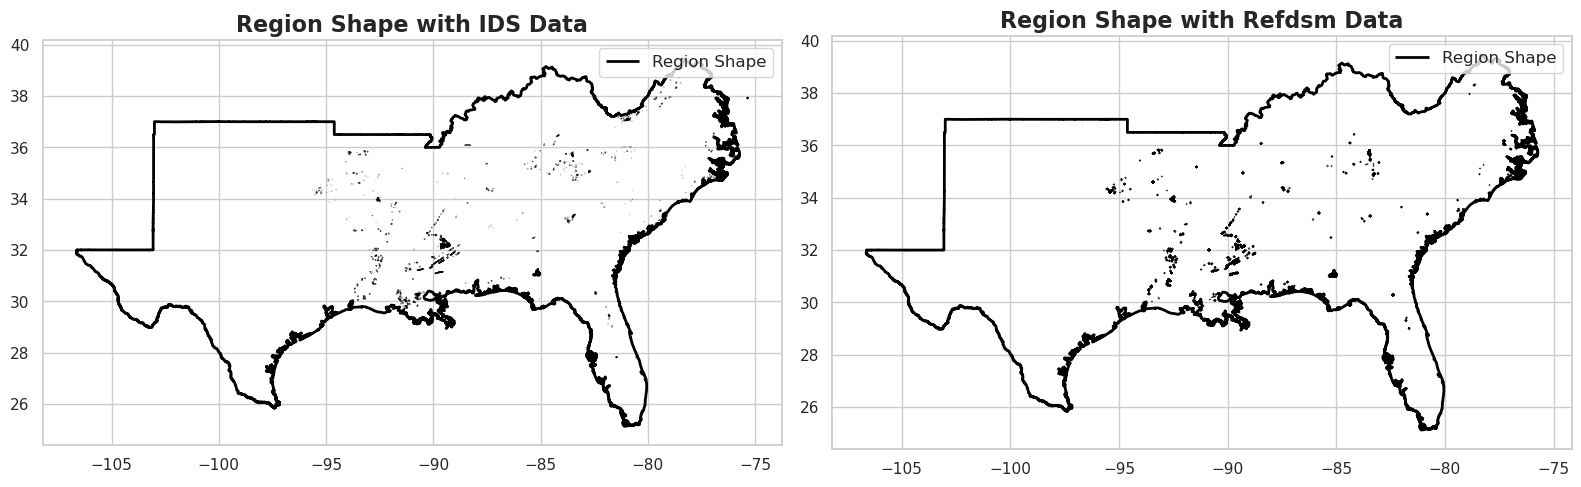

In [25]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side by side
fig, ax = plt.subplots(1, 2, figsize=(16, 8))  # Increased figsize for better visibility

# Plot the region shape and ids_gdf in the first subplot with thicker boundaries and higher opacity
region_shape.boundary.plot(ax=ax[0], linewidth=2, color='black', label='Region 8')  # Thicker boundary
ids_gdf.plot(ax=ax[0], color='blue', alpha=0.7, edgecolor='black', linewidth=1, label='IDS Data')  # Higher alpha and bold edges

# Customize the first plot
ax[0].set_title('Region 8 with IDS Data', fontsize=16, fontweight='bold')  # Bigger title
ax[0].legend(fontsize=12)  # Larger legend

# Plot the region shape and refdm_gdf in the second subplot with similar adjustments
region_shape.boundary.plot(ax=ax[1], linewidth=2, color='black', label='Region 8')  # Thicker boundary
refdm_gdf.plot(ax=ax[1], color='green', alpha=0.7, edgecolor='black', linewidth=1, label='Refdm Data')  # Higher alpha and bold edges

# Customize the second plot
ax[1].set_title('Region 8 with Refdsm Data', fontsize=16, fontweight='bold')  # Bigger title
ax[1].legend(fontsize=12)  # Larger legend

# Adjust layout for better spacing and display the plots
plt.tight_layout()
plt.show()


# Plot region 8

In [2]:
import sys
import os
sys.path.insert(1, '../Tools/')
import argparse 
from shapely.geometry import box
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import xarray as xr
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import os
import xarray as xr
import rioxarray
from shapely.geometry import Polygon
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
from shapely import wkt

from pathlib import Path
import geopandas as gpd
from tqdm import tqdm  # For progress bars
from dotenv import load_dotenv

In [26]:
import os
from pathlib import Path
import xarray as xr
import geopandas as gpd
import pandas as pd
from shapely.geometry import Polygon
from dotenv import load_dotenv
from tqdm import tqdm  # Import tqdm for the progress bar
import numpy as np

# Load environment variables from .env file
env_path = Path('/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/environment/.env')
load_dotenv(dotenv_path=env_path)

# Retrieve environment variables
s2_minicubes_folder = os.getenv('SENTINEL1_TILES')
print(f"Equi7 grids folder: {s2_minicubes_folder}")

# Check if the folder exists
if not os.path.isdir(s2_minicubes_folder):
    raise FileNotFoundError(f"The folder {s2_minicubes_folder} does not exist.")

# Initialize a list to store the results
results = []

# Iterate over files in the directory with a progress bar
for file_name in tqdm(os.listdir(s2_minicubes_folder), desc="Processing files"):
    file_path = os.path.join(s2_minicubes_folder, file_name)
    
    # Skip non-file entries (e.g., directories)
    if not os.path.isfile(file_path):
        continue

    # Check for NetCDF files based on file extension
    if not file_name.endswith('.nc'):
        continue

    # Load the NetCDF file with xarray
    try:
        ds = xr.open_dataset(file_path)

        # Try to extract x_bnds and y_bnds, or fall back to x and y if they don't exist
        if 'x_bnds' in ds and 'y_bnds' in ds:
            x_bnds = ds['x_bnds'].values
            y_bnds = ds['y_bnds'].values

            # Get the min/max x and y bounds
            x_min = np.min(x_bnds)
            x_max = np.max(x_bnds)
            y_min = np.min(y_bnds)
            y_max = np.max(y_bnds)

        elif 'x' in ds and 'y' in ds:
            x_vals = ds['x'].values
            y_vals = ds['y'].values

            # Use min and max of x and y as bounds
            x_min = np.min(x_vals)
            x_max = np.max(x_vals)
            y_min = np.min(y_vals)
            y_max = np.max(y_vals)

        else:
            raise ValueError(f"No 'x_bnds' or 'x' found in file {file_name}")

        # Create a polygon from the bounding box
        bounding_box = Polygon([
            (x_min, y_min),  # Bottom-left
            (x_max, y_min),  # Bottom-right
            (x_max, y_max),  # Top-right
            (x_min, y_max),  # Top-left
            (x_min, y_min)   # Close the polygon
        ])

        # Append the filename and bounding box to results
        results.append({
            'filename': file_name,
            'geometry': bounding_box
        })

        print(f"Processed file: {file_name}")

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")
        continue

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

# Convert DataFrame to GeoDataFrame with the original CRS (assumed EQUI7 here)
results_gdf = gpd.GeoDataFrame(results_df, geometry='geometry', crs='EPSG:27705')  # Replace with the correct CRS if different
results_gdf


Equi7 grids folder: /net/projects/forexd/WP1/Data/S1_TILES_R8/s1_change_detection_northamerica/


Processing files:   4%|▍         | 4/102 [00:00<00:05, 17.64it/s]

Processed file: EQUI7_NA020M_E087N030T3_rqatrend_VH_A_thresh_3.0_year_2021_cluster_compressed.nc
Processed file: EQUI7_NA020M_E084N030T3_rqatrend_VH_A_thresh_3.0_year_2017_cluster.nc
Processed file: EQUI7_NA020M_E087N030T3_rqatrend_VH_A_thresh_3.0_year_2016_cluster_compressed.nc
Processed file: EQUI7_NA020M_E084N024T3_rqatrend_VH_A_thresh_3.0_year_2019_cluster_compressed.nc


Processing files:   8%|▊         | 8/102 [00:00<00:05, 18.45it/s]

Processed file: EQUI7_NA020M_E087N027T3_rqatrend_VH_A_thresh_3.0_year_2020_cluster_compressed.nc
Processed file: EQUI7_NA020M_E099N033T3_rqatrend_VH_A_thresh_3.0_year_2019_cluster_compressed.nc
Processed file: EQUI7_NA020M_E096N027T3_rqatrend_VH_A_thresh_3.0_year_2017_cluster_compressed.nc
Processed file: EQUI7_NA020M_E087N027T3_rqatrend_VH_A_thresh_3.0_year_2017_cluster_compressed.nc


...

Processing files:  98%|█████████▊| 100/102 [00:05<00:00, 17.53it/s]

Processed file: EQUI7_NA020M_E099N030T3_rqatrend_VH_A_thresh_3.0_year_2021_cluster_compressed.nc
Processed file: EQUI7_NA020M_E087N024T3_rqatrend_VH_A_thresh_3.0_year_2018_cluster_compressed.nc
Processed file: EQUI7_NA020M_E084N027T3_rqatrend_VH_A_thresh_3.0_year_2021_cluster_compressed.nc
Processed file: EQUI7_NA020M_E096N024T3_rqatrend_VH_A_thresh_3.0_year_2018_cluster_compressed.nc


Processing files: 100%|██████████| 102/102 [00:05<00:00, 17.73it/s]

Processed file: EQUI7_NA020M_E099N030T3_rqatrend_VH_A_thresh_3.0_year_2016_cluster_compressed.nc
Processed file: EQUI7_NA020M_E084N027T3_rqatrend_VH_A_thresh_3.0_year_2016_cluster_compressed.nc


,filename,geometry
0,EQUI7_NA020M_E087N030T3_rqatrend_VH_A_thresh_3...,"POLYGON ((8700000 3000020, 9000000 3000020, 90..."
1,EQUI7_NA020M_E084N030T3_rqatrend_VH_A_thresh_3...,"POLYGON ((8400000 3000020, 8700000 3000020, 87..."
2,EQUI7_NA020M_E087N030T3_rqatrend_VH_A_thresh_3...,"POLYGON ((8700000 3000020, 9000000 3000020, 90..."
3,EQUI7_NA020M_E084N024T3_rqatrend_VH_A_thresh_3...,"POLYGON ((8400000 2400020, 8699980 2400020, 86..."
4,EQUI7_NA020M_E087N027T3_rqatrend_VH_A_thresh_3...,"POLYGON ((8700000 2700020, 9000000 2700020, 90..."
...,...,...
95,EQUI7_NA020M_E087N024T3_rqatrend_VH_A_thresh_3...,"POLYGON ((8700000 2400020, 9000000 2400020, 90..."
96,EQUI7_NA020M_E084N027T3_rqatrend_VH_A_thresh_3...,"POLYGON ((8400000 2700020, 8699980 2700020, 86..."
97,EQUI7_NA020M_E096N024T3_rqatrend_VH_A_thresh_3...,"POLYGON ((9600000 2400020, 9900000 2400020, 99..."
98,EQUI7_NA020M_E099N030T3_rqatrend_VH_A_thresh_3...,"POLYGON ((9900000 3000020, 10200000 3000020, 1..."


Reprojected GeoDataFrame:


<Axes: >

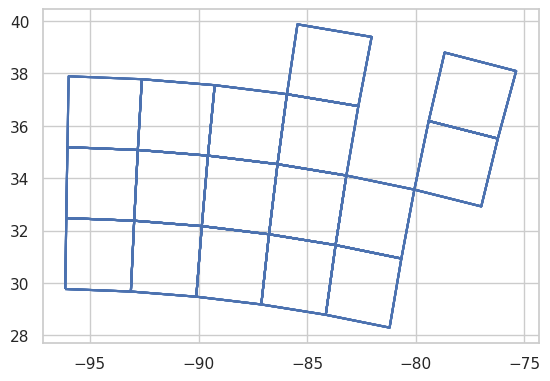

In [27]:
result_path = f"{os.getenv('RESULTS')}/radar_results/s1cd_tiles_bounds_region_{region_id}.shp"
# Reproject to EPSG:4326 (WGS 84)
results_gdf = results_gdf.to_crs(epsg=4326)
results_gdf.to_file(result_path)
# Display the GeoDataFrame
print("Reprojected GeoDataFrame:")
results_gdf.boundary.plot()

In [28]:
def get_mainland(gdf_path):
    """
    Cleans the mainland parts of specified regions from the given GeoDataFrame.
    
    Parameters:
        gdf_path (str): Path to the input GeoDataFrame file.
    
    Returns:
        GeoDataFrame: Cleaned GeoDataFrame with mainland parts of specified regions.
    """
    gdf = gpd.read_file(gdf_path)
    regions_to_clean = ['05', '10']
    cleaned_parts = []

    for region in regions_to_clean:
        region_gdf = gdf[gdf['REGION'] == region]
        exploded = region_gdf.explode(index_parts=True)
        exploded['area'] = exploded.area
        # Get the mainland part with the maximum area
        mainland_part = exploded.loc[exploded['area'].idxmax()]
        cleaned_region = exploded[exploded['area'] == mainland_part['area']]
        cleaned_parts.append(cleaned_region)

    cleaned_parts_gdf = gpd.GeoDataFrame(pd.concat(cleaned_parts, ignore_index=True))

    # Combine cleaned parts with the rest of the GeoDataFrame
    #usa_mainland = gdf[~gdf['REGION'].isin(regions_to_clean)].append(cleaned_parts_gdf, ignore_index=True)

    # Update mainland by removing small parts and adding cleaned parts
    usa_mainland = pd.concat([gdf[~gdf['REGION'].isin(regions_to_clean)], cleaned_parts_gdf], ignore_index=True)

    return usa_mainland


def get_region_shape(path, region_id):
    
    usa = gpd.read_file(path)
    country = usa[usa.REGION == region_id]
    
    region = country.explode()[0:1] 

    return region
    

def load_refdm_dataset(refdm_path):
    """
    Load and process the REFDM dataset by dissolving it based on the USDA_IDX column.

    Parameters:
        refdm_path (str): Path to the REFDM shapefile.
    
    Returns:
        GeoDataFrame: Processed REFDM GeoDataFrame with unique events.
    """
    # Load the shapefile using geopandas
    refdm_dataset = gpd.read_file(refdm_path)

    # Print CRS and dataset size
    print("CRS:", refdm_dataset.crs)
    print(f"Size of refdm_dataset: {len(refdm_dataset)}")

    # Dissolve the dataset by the USDA_IDX column
    refdm_dissolved = refdm_dataset.dissolve(by='IDX_D')  
    print(f"Size of unique refdm_dataset events: {len(refdm_dissolved)}")

    # Reset the index
    refdm_dissolved.reset_index(inplace=True)
    
    return refdm_dissolved


def load_ids_dataset(path):
    gdf_ids = gpd.read_file(path)
    #gdf_ids = gdf.rename(columns={'index_usda': 'USDA_IDX'})
    return gdf_ids


def load_tcc_dataset(tcc_nc_path):
    """
    Load and process the REFDM dataset by dissolving it based on the USDA_IDX column.

    Parameters:
        refdm_path (str): Path to the REFDM shapefile.
    
    Returns:
        GeoDataFrame: Processed REFDM GeoDataFrame with unique events.
    """
    # Load the shapefile using geopandas
    tcc_dataset = xr.open_dataset(tcc_nc_path)
    return tcc_dataset


def create_downsampled_tcc_map(forest_map_path, area_path, region_id, forest_map_downsampled_path, forest_map_downsampled_path_final):

    try:
        print("Step 1: Get Region 8 geometry ...")
        # Get Region 8 geometry
        r8_geometry = get_region_shape(area_path, region_id)
        r8_union = r8_geometry.unary_union

        print("Step 2: Load the forest map TIFF file ...")
        # Load the forest map TIFF file
        forest_map = rioxarray.open_rasterio(forest_map_path, masked=True).squeeze()

        print("Step 3: Ensure the CRS is EPSG:4326")
        # Ensure the CRS is EPSG:4326
        forest_map = forest_map.rio.write_crs("EPSG:4326")

        print("Step 4: Coarsen the data to reduce memory usage ...")
        factor = 100  # Adjust this factor as needed to reduce memory usage
        forest_map = forest_map.coarsen(x=factor, y=factor, boundary='trim').mean()

        print("Step 5: Crop the forest map to Region 8 ...")
        # Crop the forest map to Region 8
        forest_map_downsampled_cropped = forest_map.rio.clip([r8_union], forest_map.rio.crs, drop=True, from_disk=True)

        # Path to the cropped NetCDF file
        forest_map_downsampled_cropped.to_netcdf(forest_map_downsampled_path)
        print(f"Step 6: Cropped NetCDF file saved to {forest_map_downsampled_path}")

        print("Step 7: Load the cropped NetCDF file using xarray ...")
        loaded_tcc_region_8 = xr.open_dataset(forest_map_downsampled_path)

        print("Step 8: Restructure the data")
        # Rename the variable from __xarray_dataarray_variable__ to tcc
        loaded_tcc_region_8 = loaded_tcc_region_8.rename({'__xarray_dataarray_variable__': 'tcc'})
        # Remove the spatial_ref variable
        loaded_tcc_region_8 = loaded_tcc_region_8.drop_vars('spatial_ref')

        print("Step 9: Save the final NetCDF file ...")
        loaded_tcc_region_8.to_netcdf(forest_map_downsampled_path_final, mode='w')
        print(f"Step 10: Saved final NetCDF file to {forest_map_downsampled_path_final}")

    except Exception as e:
        print(f"An error occurred: {e}")
        return None

    finally:
        # Delete intermediate file
        if os.path.exists(forest_map_downsampled_path):
            os.remove(forest_map_downsampled_path)
            print(f"Step 11: Deleted intermediate file: {forest_map_downsampled_path}")


def normalize_tcc(cropped_forest):
    """
    Normalize the 'tcc' values in the cropped forest data to range between 0 and 100.
    """
    cropped_forest['tcc'] = (cropped_forest['tcc'] / cropped_forest['tcc'].max()) * 100
    cropped_forest['tcc'] = cropped_forest['tcc'].clip(min=0, max=100)
    return cropped_forest

def plot_mainland_map(ax, usa_mainland):
    """
    Plot the entire USA mainland with Region 8 highlighted.
    """
    usa_mainland[usa_mainland['REGION'] != '08'].plot(ax=ax, color='grey', edgecolor='grey')
    usa_mainland[usa_mainland['REGION'] == '08'].plot(ax=ax, color='black', edgecolor='black')
    ax.set_xlabel('Longitude', fontsize=18)
    ax.set_ylabel('Latitude', fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.grid(True)
    ax.axis('on')

def create_custom_colormap():
    """
    Create a custom colormap for the TCC plot.
    """
    cmap = plt.colormaps['Greens']
    new_colors = cmap(np.linspace(0, 1, 100))
    new_colors[0, :] = [1, 1, 1, 1]  # Set the first color (corresponding to 0) to white
    return LinearSegmentedColormap.from_list('CustomGreens', new_colors)

def plot_tcc_map(ax, cropped_forest, custom_cmap):
    """
    Plot the TCC map within Region 8 boundaries.
    """
    plot = cropped_forest['tcc'].plot(ax=ax, cmap=custom_cmap, add_colorbar=False)
    cbar = plt.colorbar(plot, ax=ax, orientation='horizontal', pad=0.05, aspect=10, shrink=0.8)
    #cbar.ax.set_position([0.15, 0.2, 0., 0.03])  # [left, bottom, width, height]
    cbar.ax.set_position([0.35, 0.31, 0.35, 0.03])  # [left, bottom, width, height]
    cbar.set_ticks([0, 25, 50, 75, 100])
    cbar.set_ticklabels(['0', '25', '50', '75', '100'])
    cbar.ax.tick_params(labelsize=16)
    cbar.set_label('Tree Canopy Cover (%)', fontsize=16, labelpad=6)
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.xaxis.label.set_size(16)
    cbar.ax.xaxis.labelpad = 10

def plot_disturbance_types(ax, refdm_dissolved, custom_colors):
    """
    Plot disturbance types within Region 8 with corresponding colors and white edges.
    """
    for disturbance, color in custom_colors.items():
        # Plot with white edge first
        refdm_dissolved[refdm_dissolved['DCA_ID'] == disturbance].plot(
            ax=ax, linewidth=3.5, color=color, edgecolor='white'
        )
        # Then plot with actual color and thinner edge
        refdm_dissolved[refdm_dissolved['DCA_ID'] == disturbance].plot(
            ax=ax, linewidth=2.5, color=color, edgecolor=color
        )


In [29]:
def parse_custom_colors(colors_json):
    """
    Parse a JSON string to extract custom color mappings.

    Parameters:
    colors_json (str): A JSON string containing color mappings where keys are color names
                       and values are color codes.

    Returns:
    dict: A dictionary containing color mappings extracted from the JSON string. 
          Returns an empty dictionary if the input JSON string is empty or None.
    """
    # Check if the JSON string is provided
    if colors_json:
        try:
            # Attempt to parse the JSON string into a Python dictionary
            custom_colors = json.loads(colors_json)
        except json.JSONDecodeError:
            # Handle JSON decoding errors (e.g., invalid JSON format)
            print("Error: Invalid JSON format.")
            custom_colors = {}
    else:
        # Default to an empty dictionary if the JSON string is empty or None
        custom_colors = {}

    return custom_colors


In [30]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

def plot_figure_1(cropped_forest, usa_mainland, r8, data, s1cd, custom_colors, save_dir):
    """
    Plot the TCC map with disturbance types and save the figure.
    """
    # Normalize the TCC values
    cropped_forest = normalize_tcc(cropped_forest)
    
    # Set Seaborn style
    sns.set(style="whitegrid")
    
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    
    # Plot the entire USA in grey in the upper left corner
    sub_ax = fig.add_axes([-0.05, 0.75, 0.25, 0.25])  # [left, bottom, width, height]
    plot_mainland_map(sub_ax, usa_mainland)
    
    # Create a custom colormap
    custom_cmap = create_custom_colormap()
    
    # Plot the TCC map within Region 8 boundaries
    plot_tcc_map(ax, cropped_forest, custom_cmap)
    
    # Plot the region outline with grids
    r8.boundary.plot(ax=ax, linewidth=2, color='#297045')
    
    # Plot S1CD boundaries with grid lines
    s1cd.boundary.plot(ax=ax, linewidth=2, color='#150442')
    # Add gridlines for s1cd
    s1cd.boundary.plot(ax=ax, linestyle='--', color='#150442', linewidth=0.5)
    
    # Plot disturbance types
    plot_disturbance_types(ax, data, custom_colors)
    
    # Customize the plot
    ax.axis('off')  # Remove axis and frame
    ax.set_title(' ')
    # Create legend for disturbance types
    legend_patches = [mpatches.Patch(color=color, label=disturbance.capitalize()) for disturbance, color in custom_colors.items()]
    ax.legend(handles=legend_patches, fontsize=18, title="IDS Disturbance Type", title_fontsize=20, loc='center left', facecolor='white', framealpha=1)
    
    # Add a label indicating the grid lines for s1cd
    ax.text(0.80, 0.45, 'S1CD Grids', transform=ax.transAxes, fontsize=20, color='#150442', bbox=dict(facecolor='white', alpha=1, edgecolor='#150442'))

    # Save the plot
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    plt.savefig(os.path.join(save_dir, 'p1_f1_ids.png'), bbox_inches='tight')
    plt.show()


In [31]:
# Retrieve environment variables
s2_minicubes_folder = os.getenv('EQUI7_GRIDS')
print(f"Equi7 grids folder: {s2_minicubes_folder}")

# Retrieve and parse custom color settings from environment variables
custom_colors_json = os.getenv('COLORS')
custom_colors = parse_custom_colors(custom_colors_json)

# Retrieve the CRS (Coordinate Reference System) for Equi7 NA
equi7_crs = os.getenv('EQUI7_NA_EPSG')

# Ensure the 'REGION' environment variable is set
region = os.getenv('REGION')
if region is None:
    raise ValueError("The 'REGION' environment variable is not set. Please ensure it is defined in the .env file.")

# Format region ID as a two-digit string
region_id = str(region).zfill(2)
forest_map_path = f"{os.getenv('TCC_PATH')}/wp1_nlcd_tcc_conus_2017_v2021_4_20m_EPSG_4326_cropped_region_08.tif"
forest_map_downsampled_path = f"{os.getenv('TCC_PATH')}/intermediate_tcc_map_region_8.nc"
tcc_map_region_8 = f"{os.getenv('TCC_PATH')}/tcc_map_region_8.nc"
figure_dir = f"{os.getenv('FIGURES')}"
area_path = f"{os.getenv('REGION_SHAPE')}/S_USA.AdministrativeRegion.shp"
ids_path = f"{os.getenv('RESULTS')}/region{region_id}_dca_filtered_ids_usda_polygons.shp"
refdm_path = f"{os.getenv('RESULTS')}/radar_results/radar_enhanced_forest_disturbance_mapping_region_{region_id}.shp"
# Save the results to a shapefile
s1cd_path = f"{os.getenv('RESULTS')}/radar_results/s1cd_tiles_bounds_region_08.shp"
s1cd = gpd.read_file(s1cd_path)

Equi7 grids folder: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/grids/


In [32]:
print("Load the USA Mainland and Region 8 Shape ...")
mainland = get_mainland(area_path)
region_8 = get_region_shape(area_path, region_id=region_id)

print("Load the Forest Disturbances ...")
refdm_dissolved = load_refdm_dataset(refdm_path)
ids =load_ids_dataset(ids_path)

# Uncomment the following line to create the downsampled TCC map
create_downsampled_tcc_map(forest_map_path, area_path, region_id, forest_map_downsampled_path, tcc_map_region_8)

print("Load the TCC Region 8 Map ...")
tcc_dataset = load_tcc_dataset(tcc_map_region_8)

Load the USA Mainland and Region 8 Shape ...
Load the Forest Disturbances ...


/tmp/ipykernel_353959/1754473181.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  exploded['area'] = exploded.area
/tmp/ipykernel_353959/1754473181.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  exploded['area'] = exploded.area


CRS: EPSG:4326
Size of refdm_dataset: 3779
Size of unique refdm_dataset events: 1707
Load the TCC Region 8 Map ...


Plot Study area figure ...


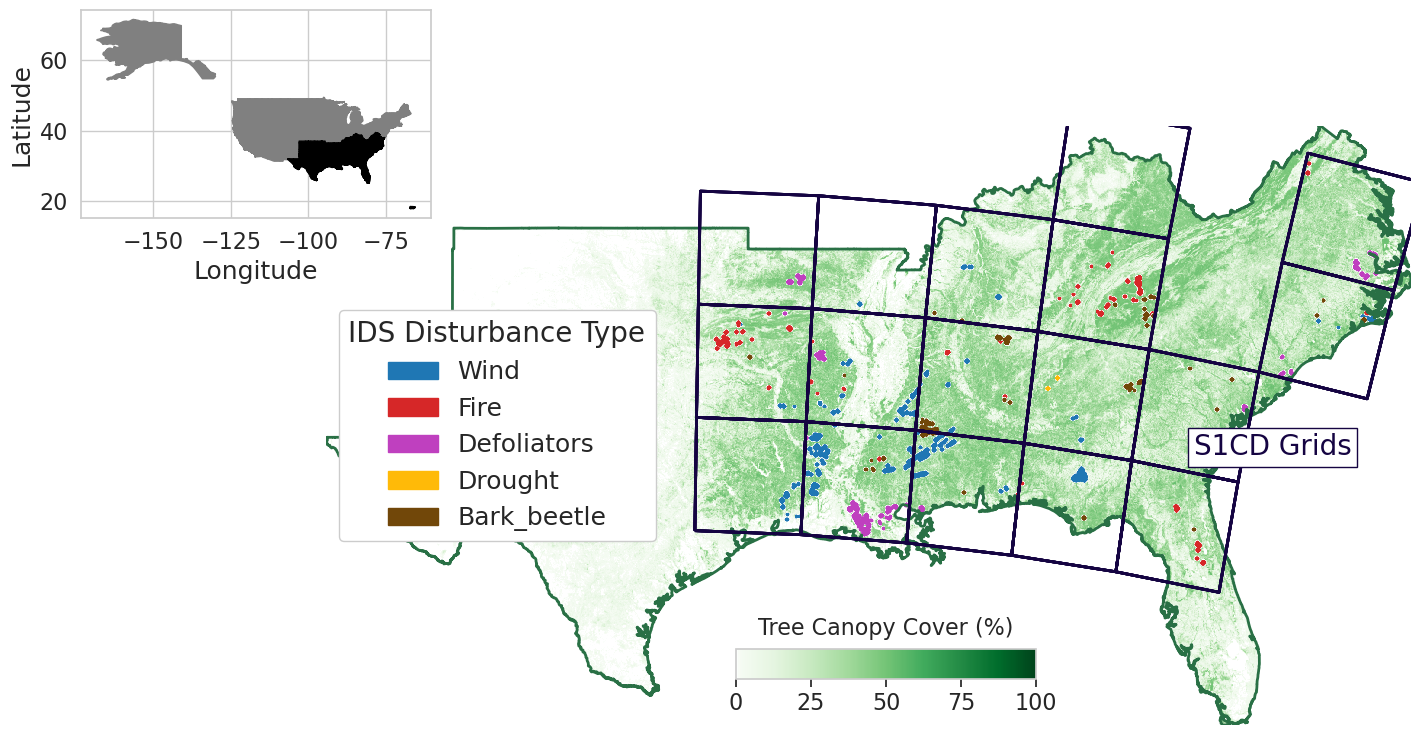

In [35]:
print("Plot Study area figure ...")
plot_figure_1(tcc_dataset, mainland, region_8, refdm_dissolved, s1cd, custom_colors, save_dir=figure_dir)

Plot Study area figure ...


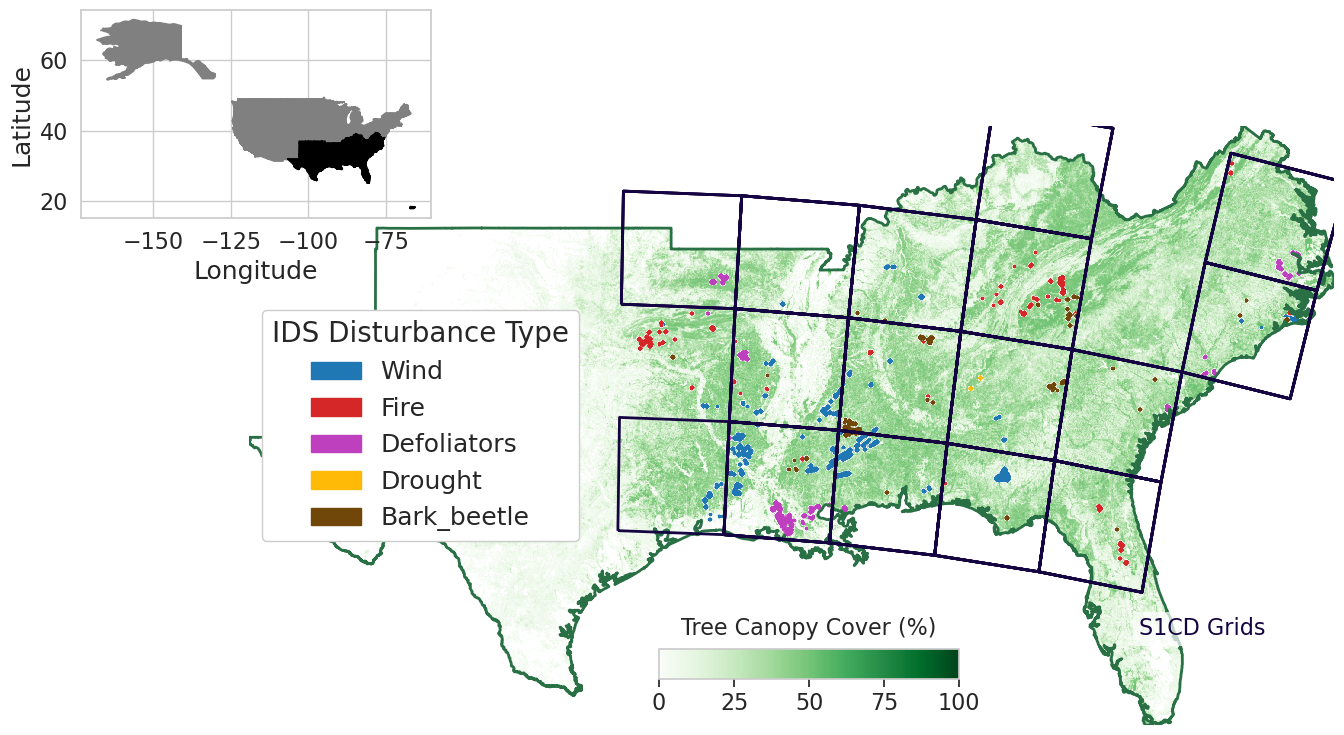

In [88]:
print("Plot Study area figure ...")
plot_figure_1(tcc_dataset, mainland, region_8, refdm_dissolved, s1cd, custom_colors, save_dir=figure_dir)

# Add Grid numbers to refdm

In [14]:
# Load environment variables from the .env file
env_path = Path('/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/environment/.env')
load_dotenv(dotenv_path=env_path)

# Retrieve environment variables
s2_minicubes_folder = os.getenv('EQUI7_GRIDS')
print(f"Equi7 grids folder: {s2_minicubes_folder}")

# Retrieve the CRS (Coordinate Reference System) for Equi7 NA
equi7_crs = os.getenv('EQUI7_NA_EPSG')

# Ensure the 'REGION' environment variable is set
region = os.getenv('REGION')
if region is None:
    raise ValueError("The 'REGION' environment variable is not set. Please ensure it is defined in the .env file.")

# Format region ID as a two-digit string
region_id = str(region).zfill(2)

# Parameters for the grid
resolution = 10
pixel_size = 512

# Define file paths for shapefiles and output locations
usa_filepath = f"{os.getenv('REGION_SHAPE')}/S_USA.AdministrativeRegion.shp"
ids_path = f"{os.getenv('RESULTS')}/region{region_id}_dca_filtered_ids_usda_polygons.shp"
refdm_path = f"{os.getenv('RESULTS')}/radar_results/radar_enhanced_forest_disturbance_mapping_region_{region_id}.shp"
output_path_grid = f"{s2_minicubes_folder}/grid_equi7_{resolution}_{pixel_size}_region_{region_id}.shp"
output_path_refdm = f"{os.getenv('RESULTS')}/radar_results/radar_enhanced_forest_disturbance_mapping_region_{region_id}_epsg_27705.shp"
output_path_intersetion = f"{s2_minicubes_folder}/grid_equi7_{resolution}_{pixel_size}_region_{region_id}_intersetion.shp"


print(f"Loading REFDM shapefile from: {refdm_path}")
refdm_gdf = gpd.read_file(refdm_path)
grid_gdf = gpd.read_file(output_path_intersetion)

# # Step 1: Read the REFDM and USDA IDs shapefiles
# print(f"Loading REFDM shapefile from: {output_path_refdm}")
# reprojected_refdm = gpd.read_file(output_path_refdm)
# reprojected_refdm
# # Step 4: Reproject the convex hulls to Equi7 CRS
# print(f"Reprojecting REFDM hulls to CRS: {equi7_crs}")
# reprojected_refdm = refdm_gdf.to_crs(equi7_crs)
# reprojected_refdm.to_file(output_path_refdm)
# reprojected_refdm

Equi7 grids folder: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/grids/
Loading REFDM shapefile from: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results//radar_results/radar_enhanced_forest_disturbance_mapping_region_08.shp


In [13]:
def add_minicube_index(intersected_grid, refdm, output):

    reprojected_refdm = refdm.to_crs(equi7_crs)

    # Ensure both GeoDataFrames are in the same CRS for proper spatial operations
    if reprojected_refdm.crs != intersected_grid.crs:
        intersected_grid = intersected_grid.to_crs(reprojected_refdm.crs)

    # Function to get intersecting indices
    def get_intersecting_indices(geometry, grid):
        intersecting_indices = grid[grid.intersects(geometry)].index.tolist()
        return intersecting_indices

    # Apply the function to each row in reprojected_refdm
    reprojected_refdm['minicube_index'] = reprojected_refdm['geometry'].apply(lambda geom: get_intersecting_indices(geom, intersected_grid))

    # Add the 'cube_amount' column by counting the length of each list in 'minicube_index'
    reprojected_refdm['cube_amount'] = reprojected_refdm['minicube_index'].apply(len)

    reprojected_refdm.to_file(output)
    return reprojected_refdm

In [16]:
reprojected_refdm = add_minicube_index(grid_gdf, refdm_gdf, output_path_refdm)
reprojected_refdm

/tmp/ipykernel_1264478/2495646023.py:20: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  reprojected_refdm.to_file(output)
/net/home/fmueller/.conda/envs/emp/lib/python3.12/site-packages/pyogrio/raw.py:709: RuntimeWarning: Normalized/laundered field name: 'minicube_index' to 'minicube_i'
  ogr_write(
/net/home/fmueller/.conda/envs/emp/lib/python3.12/site-packages/pyogrio/raw.py:709: RuntimeWarning: Normalized/laundered field name: 'cube_amount' to 'cube_amoun'
  ogr_write(


,IDX_D,S1_YEAR,S1_TILE,S1CD_INDEX,ID_E,DCA_ID,SURVEY_Y,REGION_ID,DA_C_USDA,ID_O,O_Year,O_DCA_ID,O_Y_diff,area_km2,geometry,minicube_index,cube_amount
0,bark_beetle_2017_24083,2018,E087N027T3,144,24083,bark_beetle,2017,8,1,None,NaN,None,NaN,0.002292,"MULTIPOLYGON (((8979462.651 2973486.106, 89794...",[425],1
1,defoliators_2019_26042,2018,E087N027T3,1614,26042,defoliators,2019,8,2,None,NaN,None,NaN,1.625363,"MULTIPOLYGON (((8728098.124 2876033.314, 87280...","[164, 165, 188]",3
2,defoliators_2019_26043,2018,E087N027T3,1615,26043,defoliators,2019,8,2,None,NaN,None,NaN,0.218304,"MULTIPOLYGON (((8725403.782 2880181.255, 87253...",[165],1
3,defoliators_2019_26044,2018,E087N027T3,1616,26044,defoliators,2019,8,2,None,NaN,None,NaN,1.125013,"MULTIPOLYGON (((8724620.233 2883667.463, 87246...","[145, 166]",2
4,defoliators_2019_26045,2018,E087N027T3,1617,26045,defoliators,2019,8,2,None,NaN,None,NaN,0.354790,"MULTIPOLYGON (((8724899.017 2880345.13, 872488...","[144, 165, 166]",3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3690,fire_2019_26308,2019,E084N027T3,1762,26308,fire,2019,8,8,None,NaN,None,NaN,0.058783,"MULTIPOLYGON (((8585831.185 2983212.523, 85859...",[43],1
3691,fire_2019_26396,2019,E084N027T3,1781,26396,fire,2019,8,8,None,NaN,None,NaN,0.291336,"MULTIPOLYGON (((8505354.413 2954135.974, 85053...","[31, 32]",2
3692,wind_2019_26010,2019,E084N027T3,1593,26010,wind,2019,8,16,None,NaN,None,NaN,1.204344,"MULTIPOLYGON (((8629754.411 2738403.423, 86297...","[48, 49, 52, 53, 56]",5
3693,wind_2020_26419,2019,E084N027T3,1794,26419,wind,2020,8,16,None,NaN,None,NaN,0.022680,"MULTIPOLYGON (((8663618.444 2739756.273, 86636...",[92],1


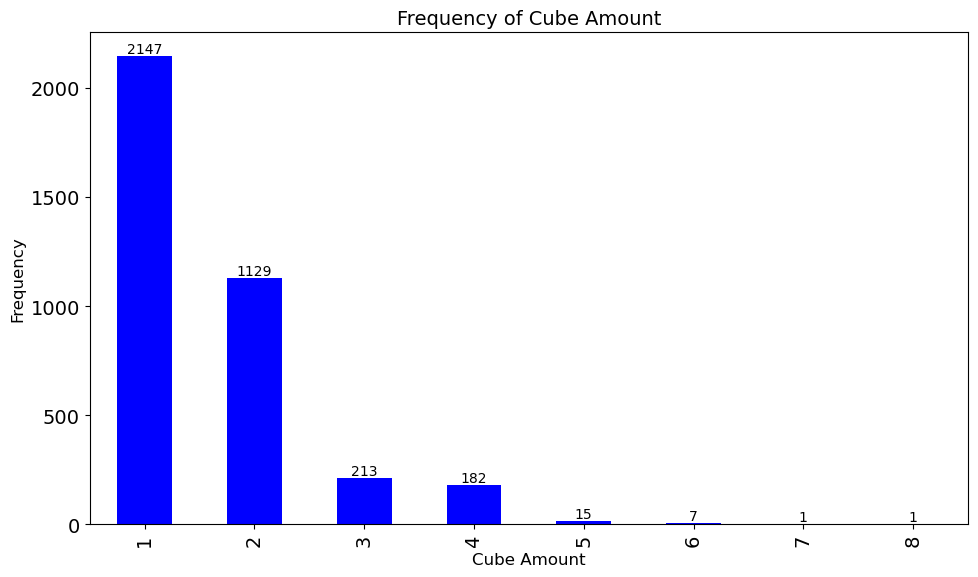

In [18]:
import matplotlib.pyplot as plt

# Bar plot
plt.figure(figsize=(10, 6))
cube_amount_counts = reprojected_refdm['cube_amount'].value_counts().sort_index()

# Plot the bar plot
ax = cube_amount_counts.plot(kind='bar', color='blue', edgecolor=None)

# Adding labels and title
plt.xlabel('Cube Amount', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Frequency of Cube Amount', fontsize=14)

# Annotate each bar with its corresponding count
for i, count in enumerate(cube_amount_counts):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)

# Display the plot
plt.tight_layout()
plt.show()


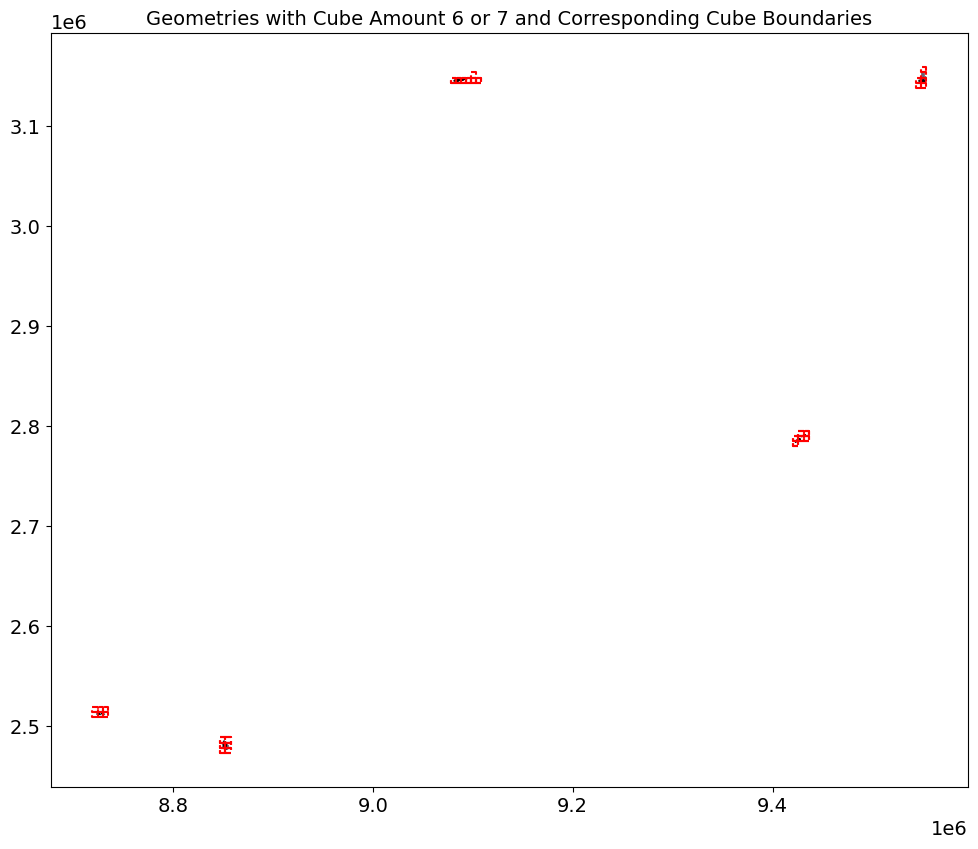

In [21]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Filter the rows where cube_amount is 6 or 7
filtered_refdm = reprojected_refdm[reprojected_refdm['cube_amount'].isin([6, 7])]

# Set up the plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the geometries from reprojected_refdm
filtered_refdm.plot(ax=ax, color='blue', edgecolor='black', alpha=0.5, label='Reprojected geometries')

# Plot the corresponding cube geometries (grid_gdf) based on minicube_index
for idx, row in filtered_refdm.iterrows():
    minicube_indices = row['minicube_index']  # List of indices from grid_gdf
    cube_geometries = grid_gdf.loc[minicube_indices]  # Extract geometries from grid_gdf
    cube_geometries.boundary.plot(ax=ax, color='red', linestyle='--', label='Cube Boundaries' if idx == 0 else "")  # Plot boundaries

# Add title and legend
plt.title('Geometries with Cube Amount 6 or 7 and Corresponding Cube Boundaries', fontsize=14)
#plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


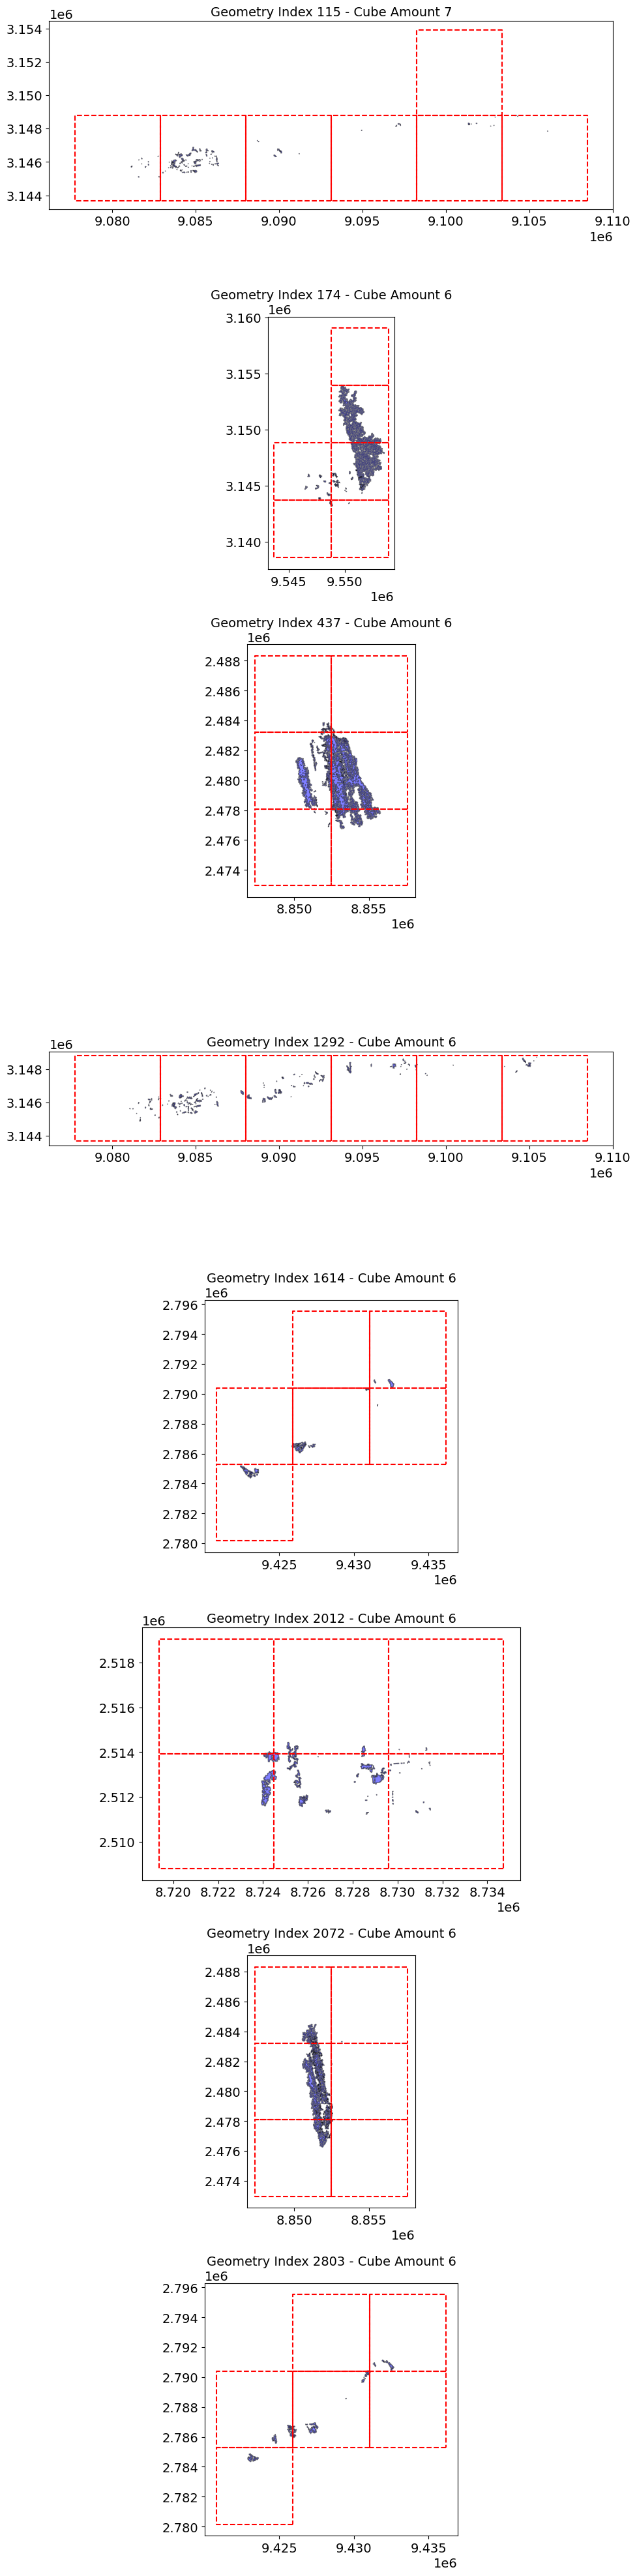

In [22]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Filter the rows where cube_amount is 6 or 7
filtered_refdm = reprojected_refdm[reprojected_refdm['cube_amount'].isin([6, 7])]

# Set up the number of subplots (1 subplot per row in filtered_refdm)
num_rows = len(filtered_refdm)
fig, axes = plt.subplots(nrows=num_rows, figsize=(10, num_rows * 5))

# Ensure axes is iterable, even if there is only one subplot
if num_rows == 1:
    axes = [axes]

# Loop through each row in filtered_refdm and plot the geometries
for i, (idx, row) in enumerate(filtered_refdm.iterrows()):
    # Plot the reprojected geometry in blue
    filtered_refdm.loc[[idx]].plot(ax=axes[i], color='blue', edgecolor='black', alpha=0.5, label='Reprojected Geometry')
    
    # Plot the corresponding cube boundaries (from grid_gdf) in red
    minicube_indices = row['minicube_index']  # List of indices from grid_gdf
    cube_geometries = grid_gdf.loc[minicube_indices]  # Extract geometries from grid_gdf
    cube_geometries.boundary.plot(ax=axes[i], color='red', linestyle='--', label='Cube Boundaries')

    # Set title for each subplot
    axes[i].set_title(f'Geometry Index {idx} - Cube Amount {row["cube_amount"]}', fontsize=14)
    #axes[i].legend()

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


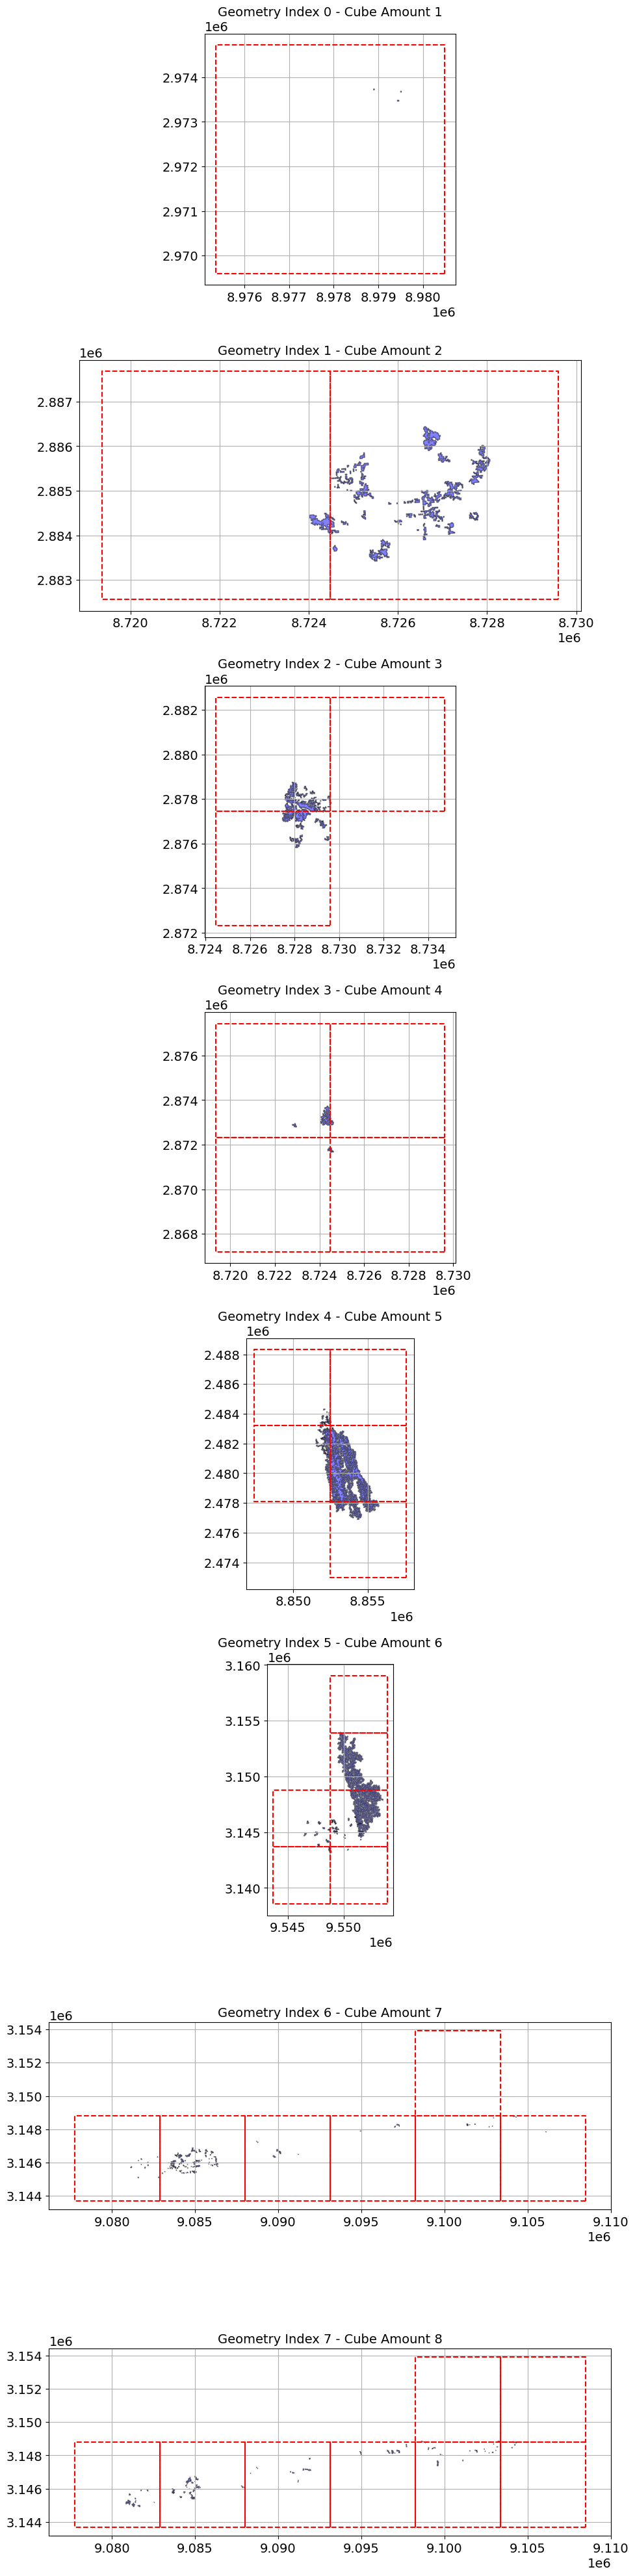

In [23]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Filter one example row for each cube_amount from 1 to 8
example_rows = []
for i in range(1, 9):
    example_row = reprojected_refdm[reprojected_refdm['cube_amount'] == i].head(1)
    if not example_row.empty:
        example_rows.append(example_row)

# Combine the selected rows into a single GeoDataFrame
example_gdf = gpd.GeoDataFrame(pd.concat(example_rows, ignore_index=True))

# Set up the number of subplots (one for each cube_amount from 1 to 8)
num_rows = len(example_gdf)
fig, axes = plt.subplots(nrows=num_rows, figsize=(10, num_rows * 5))

# Ensure axes is iterable, even if there is only one subplot
if num_rows == 1:
    axes = [axes]

# Loop through each example row and plot
for i, (idx, row) in enumerate(example_gdf.iterrows()):
    # Plot the reprojected geometry in blue
    example_gdf.loc[[idx]].plot(ax=axes[i], color='blue', edgecolor='black', alpha=0.5, label='Reprojected Geometry')
    
    # Plot the corresponding cube boundaries (from grid_gdf) in red
    minicube_indices = row['minicube_index']  # List of indices from grid_gdf
    cube_geometries = grid_gdf.loc[minicube_indices]  # Extract geometries from grid_gdf
    cube_geometries.boundary.plot(ax=axes[i], color='red', linestyle='--', label='Cube Boundaries')

    # Set title for each subplot
    axes[i].set_title(f'Geometry Index {idx} - Cube Amount {row["cube_amount"]}', fontsize=14)
    
    # Add grid to the plot
    axes[i].grid(True)

    # Show the legend
    #axes[i].legend()

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()